# 1. 데이터 기초 특성 파악

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("prj_data_eda.csv")

In [12]:
df.shape

(500, 11)

In [13]:
df.dtypes

고객ID           str
나이         float64
성별             str
거주지역           str
가입경로           str
멤버십등급          str
월평균구매금액    float64
구매횟수       float64
리뷰점수       float64
쿠폰사용여부         str
이탈여부         int64
dtype: object

In [14]:
df.describe()

,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.180000,86092.413399,7.822000,3.734800,0.380000
std,14.384764,47003.366902,4.481795,0.540382,0.485873
min,18.000000,19127.903927,1.000000,2.500000,0.000000
25%,32.000000,48362.456334,4.000000,3.400000,0.000000
50%,43.000000,74770.324856,7.000000,3.700000,0.000000
75%,56.000000,114551.098353,10.250000,4.100000,1.000000
max,69.000000,213834.061381,21.000000,5.000000,1.000000


In [15]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop("이탈여부").tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.drop("고객ID").tolist()

print("수치형 변수:", numeric_cols)
print("범주형 변수:", categorical_cols)

수치형 변수: ['나이', '월평균구매금액', '구매횟수', '리뷰점수']
범주형 변수: ['성별', '거주지역', '가입경로', '멤버십등급', '쿠폰사용여부']


In [16]:
df["거주지역"].value_counts()

거주지역
서울    155
경기    123
대구     89
부산     80
기타     53
Name: count, dtype: int64

# 2. 단변량/분포 시각화

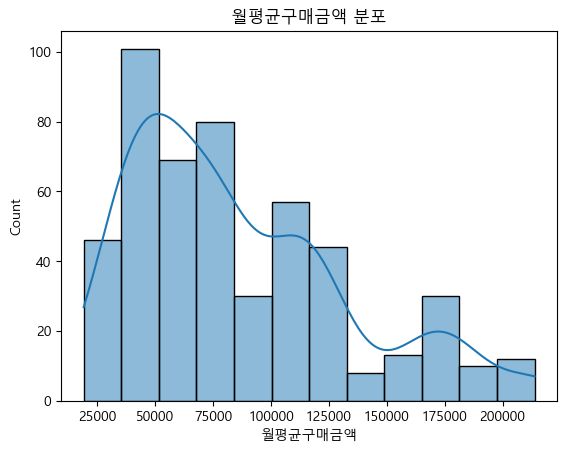

In [17]:
sns.histplot(df["월평균구매금액"], kde=True)
plt.title("월평균구매금액 분포")
plt.show()

In [18]:
df["월평균구매금액"].skew().round(2)

np.float64(0.91)

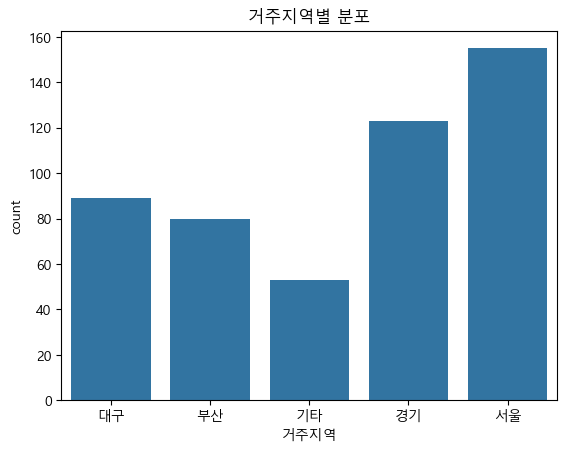

In [19]:
sns.countplot(x="거주지역", data=df)
plt.title("거주지역별 분포")
plt.show()

- 왜도가 0.91 정도로 오른쪽으로 치우친 분포다. 대부분 5~15만원대인데 20만원 넘는 사람은 몇 명 안 된다.
- 거주지역은 서울, 경기가 많고 대구, 부산, 기타는 비슷한 수준이다.

# 3. 상관관계 및 이변량 분석

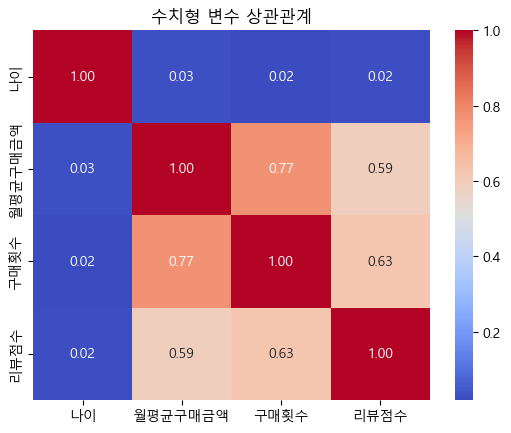

In [20]:
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("수치형 변수 상관관계")
plt.show()

최고 상관 변수 쌍: ('월평균구매금액', '구매횟수'), r=0.77


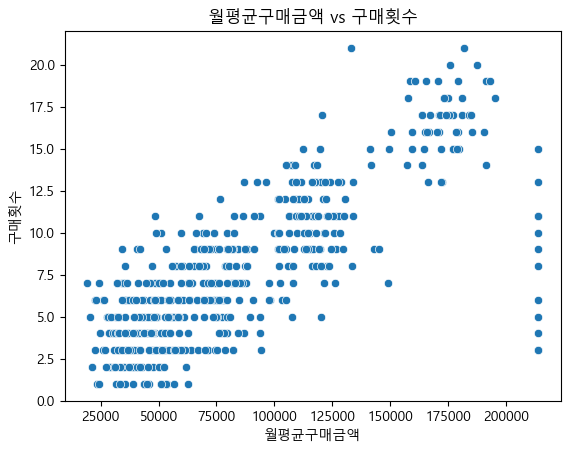

In [21]:
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pair = corr_pairs.abs().sort_values(ascending=False).index[0]
print(f"최고 상관 변수 쌍: {top_pair}, r={corr.loc[top_pair]:.2f}")

sns.scatterplot(data=df, x=top_pair[0], y=top_pair[1])
plt.title(f"{top_pair[0]} vs {top_pair[1]}")
plt.show()

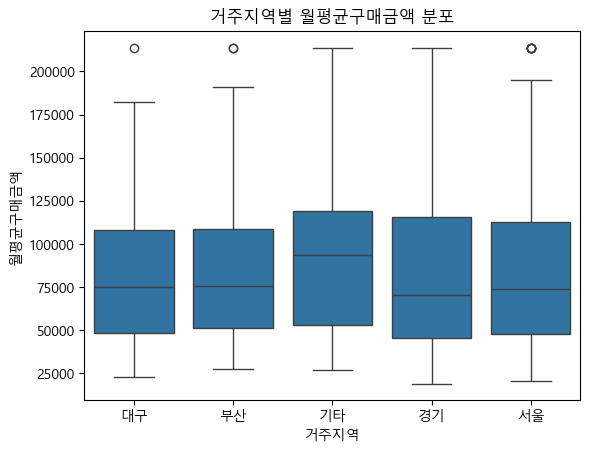

In [22]:
sns.boxplot(data=df, x="거주지역", y="월평균구매금액")
plt.title("거주지역별 월평균구매금액 분포")
plt.show()

- 구매횟수랑 월평균구매금액이 상관계수 0.77로 같이 움직인다. 근데 이건 상관관계일 뿐이고,
  구매 많이 해서 금액이 커진 건지 원래 돈 많이 쓰는 사람이 구매도 많이 한 건지는 이 데이터만으로는 알 수 없다.
- 거주지역별로 보면 금액대가 조금씩 다르게 나온다.

# 4. 그룹별 비교 분석 및 인사이트 도출

In [23]:
grp = df.groupby("멤버십등급")[["월평균구매금액", "구매횟수", "리뷰점수"]].mean()
grp

,월평균구매금액,구매횟수,리뷰점수
멤버십등급,,,
VIP,172517.993605,16.654545,4.425455
골드,118243.454740,10.774775,4.138739
브론즈,47742.216252,4.072917,3.355729
실버,79339.352497,7.161972,3.664085


In [ ]:
df.groupby(["멤버십등급", "이탈여부"])["월평균구매금액"].mean() # 이탈: 1 이탈X: 0

멤버십등급  이탈여부
VIP    0       171522.028714
       1       198911.063230
골드     0       119278.888435
       1       113805.881762
브론즈    0        47547.551617
       1        47896.856383
실버     0        77860.839415
       1        81359.987043
Name: 월평균구매금액, dtype: float64

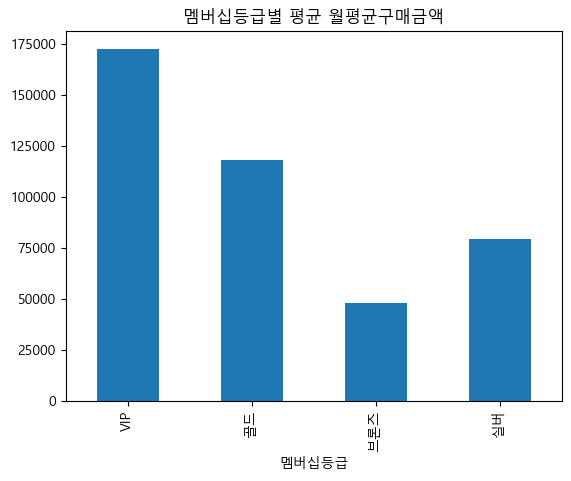

In [25]:
grp["월평균구매금액"].plot(kind="bar")
plt.title("멤버십등급별 평균 월평균구매금액")
plt.show()

### 인사이트
1. VIP는 평균 17만원, 브론즈는 4만7천원 정도로 등급 올라갈수록 구매금액이랑 구매횟수도 같이 올라간다.
   등급 혜택이 실제로 구매를 늘리는 데 도움 되는 것 같으니 상위 등급으로 유도하는 프로모션 하면 괜찮을 듯하다.
2. 같은 등급이어도 이탈한 사람이랑 안 한 사람 구매금액 차이가 난다. 등급만 봐서는 이탈을 다 설명 못하니까
   구매횟수나 리뷰점수 같이 봐서 이탈 예측하는 게 나을 것 같다.